In [1]:
from datetime import datetime, timedelta
import uo_pyfetch

import calendar
from datetime import datetime, timezone

In [2]:
bbox = [-1.652756, 54.973377, -1.620483, 54.983721]

In [3]:
variables = uo_pyfetch.get_variables()
print("Available variables:")
for v in variables["Variables"][:5]:
    print(f" - {v['Name']} ({v.get('Units', 'no units')})")

Available variables:
 - allpollu (%)
 - Ammonia (?)
 - Average Speed (KmPH)
 - Battery (V)
 - Brood (Celsius)


In [4]:
themes = uo_pyfetch.get_themes()
print("\nAvailable themes:")
for t in themes["Themes"]:
    print(f" - {t['Name']}")


Available themes:
 - Sewage
 - Sensor Metrics
 - Electrical
 - Seismic
 - Water Quality
 - Traffic
 - Air Quality
 - Water Level
 - Bee Hive
 - People
 - Building
 - Environment
 - Weather
 - Noise
 - Vehicles


In [5]:
print("\nFetching sensors in bbox...")
sensors_df = uo_pyfetch.get_sensors(limit=50, bbox=bbox)


Fetching sensors in bbox...


In [6]:
sensors_df.head()

,Sensor_Name,Location_WKT,Sensor_Centroid_Longitude,Ground_Height_Above_Sea_Level,Sensor_Centroid_Latitude,Sensor_Height_Above_Ground,Broker_Name,Raw_ID
0,PER_NEWCASTLE_STJAMES,POINT(-1.62099 54.97408),-1.62099,50.750000,54.97408,2.0,Newcastle Council RSS feed,137
1,PER_NEWCASTLE_STJAMES_METRO,POINT(-1.62099 54.97408),-1.62099,50.750000,54.97408,2.0,Newcastle Council RSS feed,220
2,PER_BUILDING_OAT_NUBS_TREND_MOM,POINT(-1.62332 54.97415),-1.62332,56.509998,54.97415,2.0,Building External Sensor,615
3,PER_BUILDING_OAT_SPORTS_HALL_TREND_MOM,POINT(-1.62469 54.98274),-1.62469,66.709999,54.98274,2.0,Building External Sensor,630
4,PER_BUILDING_OAT_RICH_RD_BLR_HSE_TREND_MOM,POINT(-1.62419 54.98162),-1.62419,64.959999,54.98162,2.0,Building External Sensor,634


In [19]:
sensors_df.Sensor_Height_Above_Ground.unique()

array([ 2., 68.])

In [7]:
print("\nFetching sensor data (last n days)...")
n = 365
sensor_data_df = uo_pyfetch.get_sensor_data(
    last_n_hours=n*24,
    variables=[],
    bbox=bbox,
    limit=1000000
)


Fetching sensor data (last n days)...


HTTPError: 504 Server Error: Gateway Timeout for url: https://api.v2.urbanobservatory.ac.uk/sensors/data/csv?limit=1000000&offset=0&last_n_hours=8760&bbox_p1_x=-1.652756&bbox_p1_y=54.973377&bbox_p2_x=-1.620483&bbox_p2_y=54.983721

In [8]:
sensor_data_df.Timestamp.sort_values(ascending=False).head(25)

NameError: name 'sensor_data_df' is not defined

In [9]:
sensor_data_df.Timestamp.sort_values(ascending=False).tail(25)

NameError: name 'sensor_data_df' is not defined

In [10]:
sensor_data_df.Variable.unique()

NameError: name 'sensor_data_df' is not defined

In [11]:
if not sensor_data_df.empty:
    sensor_name = sensor_data_df.iloc[0]["Sensor_Name"]
    print(f"\nFetching full history for sensor: {sensor_name}")
    start = datetime.now() - timedelta(days=1)
    end = datetime.now()

    sensor_specific_df = uo_pyfetch.get_sensor_data_by_name(
        sensor_name,
        start=start,
        end=end,
        variables=["NO2", "PM10"]
    )
else:
    print("\nNo sensors found in bbox.")

sensor_specific_df.head()

NameError: name 'sensor_data_df' is not defined

In [12]:
uo_pyfetch.get_variables()

{'Variables': [{'Units': '%',
   'Name': 'allpollu',
   'Upper_Limit': None,
   'Lower_Limit': None,
   'Theme': 'Air Quality'},
  {'Units': '?',
   'Name': 'Ammonia',
   'Upper_Limit': None,
   'Lower_Limit': None,
   'Theme': 'Air Quality'},
  {'Units': 'KmPH',
   'Name': 'Average Speed',
   'Upper_Limit': None,
   'Lower_Limit': None,
   'Theme': 'Vehicles'},
  {'Units': 'V',
   'Name': 'Battery',
   'Upper_Limit': None,
   'Lower_Limit': None,
   'Theme': 'Sensor Metrics'},
  {'Units': 'Celsius',
   'Name': 'Brood',
   'Upper_Limit': None,
   'Lower_Limit': None,
   'Theme': 'Bee Hive'},
  {'Units': 'Vehicles',
   'Name': 'Bus Count',
   'Upper_Limit': None,
   'Lower_Limit': None,
   'Theme': 'Vehicles'},
  {'Units': 'Vehicles',
   'Name': 'Bus Count East',
   'Upper_Limit': None,
   'Lower_Limit': None,
   'Theme': 'Vehicles'},
  {'Units': 'Vehicles',
   'Name': 'Bus Count West',
   'Upper_Limit': None,
   'Lower_Limit': None,
   'Theme': 'Vehicles'},
  {'Units': 'Vehicles',
   '

In [13]:
def get_sensor_data(dt1, dt2, bbox):
    sensor_data_df = uo_pyfetch.get_sensor_data(
        start=dt1,
        end=dt2,
        variables=None,
        bbox=bbox,
        limit=1000000
    )

    return sensor_data_df

In [15]:
bbox = [-1.652756, 54.973377, -1.620483, 54.983721]
year = 2024
for i in range(12, 13):
    start = datetime(year, i, 1)
    if i == 12:
        end = datetime(year+1, 1, 1)
    else:
        end = datetime(2024, i+1, 1)

    if i < 10:
        num = f"0{i}"
    else:
        num = str(i)

    csv_file_name = f"sensor_data_{start.strftime("%Y").lower()+f"_{num}"}.csv"

    data = get_sensor_data(start, end, bbox=bbox)
    
    data.to_csv(f"./csv_extraction/{csv_file_name}")

    

In [31]:
df = get_sensor_data(datetime(2025, 4, 10), datetime(2025, 5, 10), bbox)

In [35]:
df.head()

,Sensor_Name,Variable,Value,Timestamp,Flagged,Location_WKT,Sensor_Centroid_Longitude,Ground_Height_Above_Sea_Level,Sensor_Centroid_Latitude,Sensor_Height_Above_Ground,Broker_Name,Raw_ID
0,PER_NE_CAJT_NCA189_BR3_SJB2,Plates Out,7.000,2025-04-10 00:00:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,...",-1.628878,79.949997,54.977755,2.0,NE Travel Data API,73162
1,PER_NE_CAJT_NCA189_BR3_SJB2,Journey Time,114.000,2025-04-10 00:00:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,...",-1.628878,79.949997,54.977755,2.0,NE Travel Data API,73162
2,PER_NE_CAJT_NCA189_BR3_SJB2,Plates Matching,3.000,2025-04-10 00:00:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,...",-1.628878,79.949997,54.977755,2.0,NE Travel Data API,73162
3,PER_NE_CAJT_NCA189_BR3_SJB2,Plates In,16.000,2025-04-10 00:00:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,...",-1.628878,79.949997,54.977755,2.0,NE Travel Data API,73162
4,PER_AIRMON_MESH306245,O3,8.569,2025-04-10 00:00:00,False,POINT(-1.648605 54.977836),-1.648605,111.389999,54.977836,2.0,aq_mesh_api,79521


In [39]:
df = df.drop(columns=["Sensor_Name", "Sensor_Centroid_Longitude", "Sensor_Centroid_Latitude", "Ground_Height_Above_Sea_Level", "Sensor_Height_Above_Ground", "Broker_Name"])

In [44]:
df.head()

,Variable,Value,Timestamp,Flagged,Location_WKT,Raw_ID
0,Plates Out,7.000,2025-04-10 00:00:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,...",73162
1,Journey Time,114.000,2025-04-10 00:00:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,...",73162
2,Plates Matching,3.000,2025-04-10 00:00:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,...",73162
3,Plates In,16.000,2025-04-10 00:00:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,...",73162
4,O3,8.569,2025-04-10 00:00:00,False,POINT(-1.648605 54.977836),79521


In [61]:
df.Variable.unique()

array(['Plates Out', 'Journey Time', 'Plates Matching', 'Plates In', 'O3',
       'Particle Count', 'PM1', 'PM10', 'PM2.5', 'PM 4', 'Temperature',
       'Pressure', 'Humidity', 'NO', 'NO2', 'Walking',
       'Internal Humidity', 'Internal Temperature'], dtype=object)

In [48]:
df_plates_out = df[df["Variable"]=="Plates Out"].drop(columns=["Variable"])

In [49]:
df_plates_out.head()

,Value,Timestamp,Flagged,Location_WKT,Raw_ID
0,7.0,2025-04-10 00:00:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,...",73162
17,9.0,2025-04-10 00:00:00,False,"LINESTRING(-1.62151252520077 54.9734188344729,...",73173
21,12.0,2025-04-10 00:04:00,False,"LINESTRING(-1.62151252520077 54.9734188344729,...",73173
28,2.0,2025-04-10 00:04:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,...",73162
32,5.0,2025-04-10 00:08:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,...",73162


In [52]:
df_plates_out_73162 = df_plates_out[df_plates_out["Raw_ID"]==73162]

In [51]:
import matplotlib.pyplot as plt

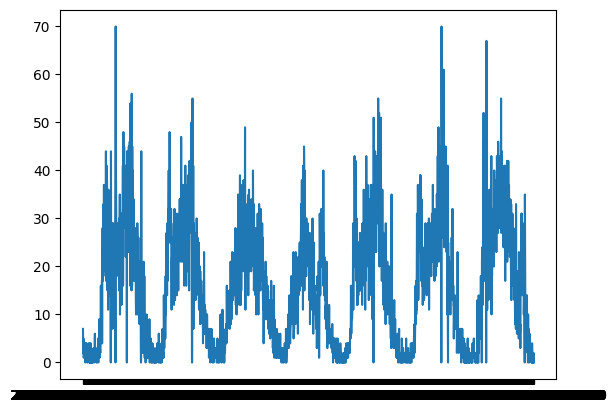

In [60]:
plt.plot(df_plates_out_73162["Timestamp"].head(2500), df_plates_out_73162["Value"].head(2500))
plt.show()

In [63]:
df.Variable.unique()

array(['Plates Out', 'Journey Time', 'Plates Matching', 'Plates In', 'O3',
       'Particle Count', 'PM1', 'PM10', 'PM2.5', 'PM 4', 'Temperature',
       'Pressure', 'Humidity', 'NO', 'NO2', 'Walking',
       'Internal Humidity', 'Internal Temperature'], dtype=object)

In [68]:
df_humidity = df[df["Variable"]=="Humidity"].drop(columns=["Variable"])
df_humidity.head()

,Value,Timestamp,Flagged,Location_WKT,Raw_ID
12,78.4,2025-04-10 00:00:00,False,POINT(-1.648605 54.977836),79521
53,78.8,2025-04-10 00:15:00,False,POINT(-1.648605 54.977836),79521
92,79.8,2025-04-10 00:30:00,False,POINT(-1.648605 54.977836),79521
135,80.7,2025-04-10 00:45:00,False,POINT(-1.648605 54.977836),79521
180,81.3,2025-04-10 01:00:00,False,POINT(-1.648605 54.977836),79521


In [69]:
df_humidity_79521 = df_humidity[df_humidity["Raw_ID"]==79521]

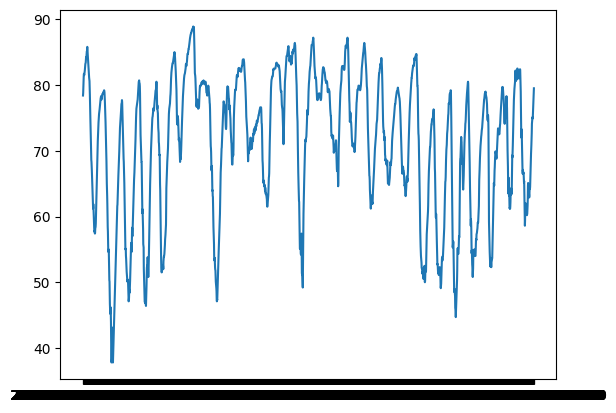

In [70]:
plt.plot(df_humidity_79521["Timestamp"].head(2500), df_humidity_79521["Value"].head(2500))
plt.show()

In [71]:
df_NO2 = df[df["Variable"]=="NO2"].drop(columns=["Variable"])
df_NO2.head()

,Value,Timestamp,Flagged,Location_WKT,Raw_ID
14,26.37264,2025-04-10 00:00:00,False,POINT(-1.648605 54.977836),79521
56,27.40664,2025-04-10 00:15:00,False,POINT(-1.648605 54.977836),79521
94,28.96704,2025-04-10 00:30:00,False,POINT(-1.648605 54.977836),79521
140,28.08344,2025-04-10 00:45:00,False,POINT(-1.648605 54.977836),79521
182,25.16944,2025-04-10 01:00:00,False,POINT(-1.648605 54.977836),79521


In [73]:
df_NO2_79521 = df_NO2[df_NO2["Raw_ID"]==79521]

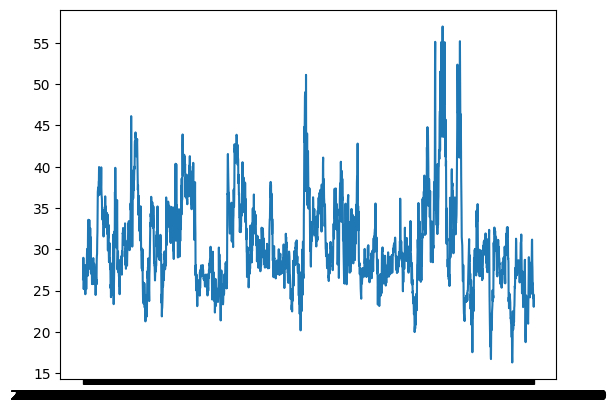

In [74]:
plt.plot(df_NO2_79521["Timestamp"].head(2500), df_NO2_79521["Value"].head(2500))
plt.show()